# Glacial Lake Dynamics in the Baba Mountains (Koh e Baba), Central Afghanistan. 

## Introduction
### 1. Study Area
The baba mountain range (koh e Baba) is located in central Afghanistan (Bamyan Province). The mountain contains numerous small glacial lakes that are highly sensitive to climate fluctuations. 

### 2. Data Extraction Methodology 
Given the relatively surface area of glacier and glacier lakes in this region, the 10m sentinel -2 Level-2A with zero cloud cover and minimal seasional snow cover was selected for this study. The selected imagery underwent segmantation followed by supervised classification using Random Forest classifier. After some manual editing using visual image interpretation techniques, and cleaning the data, all the attribute tables were calculated in ArcGIS pro environment. To facilitate modern goespatail analysis in python, the shapefile were exported to GeoJason format

### 3. Goals 

The primary assissment of this project is to perform decadle (2016-2025) change assessment to identify:
1. Change Detections (Count and Area)
2. The number of newly formad glacial lakes.
3. Maps and Visualization

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
#loading the data
Lakes_16=gpd.read_file('../Data/gl2016.geojson')
lakes_25=gpd.read_file('../Data/gl2025.geojson')

print('Data loaded successfully!')

Data loaded successfully!


In [2]:
# I want to explore and display some of the basic information about the datasets, such as the number of records,
# column names, and a preview of the data.This will help me understand the structure of the datasets 
# and identify any potential issues or insights that can be derived from them.

print('gl2016 Dataset Info')
print(Lakes_16.info())
print(Lakes_16.head())
columns_to_hide = ['geometry', 'Shape_Leng', 'Shape_Area','Shape_Length']
display(Lakes_16.drop(columns=columns_to_hide).head())    
print('2025 Dataset Info')
print(lakes_25.info())
print(lakes_25.head()) 
columns_to_hide = ['geometry', 'Shape_Length', 'Shape_Area']
display(lakes_25.drop(columns=columns_to_hide).head())



gl2016 Dataset Info
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   OBJECTID      35 non-null     int32   
 1   gridcode      34 non-null     float64 
 2   ClassName     35 non-null     object  
 3   Longitude     35 non-null     float64 
 4   Latitude      35 non-null     float64 
 5   GLIMS_ID      35 non-null     object  
 6   ClassValue    34 non-null     float64 
 7   Shape_Leng    34 non-null     float64 
 8   AreasqKM      35 non-null     float64 
 9   Altitude      35 non-null     int32   
 10  Shape_Length  35 non-null     float64 
 11  Shape_Area    35 non-null     float64 
 12  geometry      35 non-null     geometry
dtypes: float64(8), geometry(1), int32(2), object(2)
memory usage: 3.4+ KB
None
   OBJECTID  gridcode     ClassName  Longitude  Latitude         GLIMS_ID  \
0         1       2.0  Glacier_Lake     67.678    34

,OBJECTID,gridcode,ClassName,Longitude,Latitude,GLIMS_ID,ClassValue,AreasqKM,Altitude
0,1,2.0,Glacier_Lake,67.678,34.665,GL067678E34665N,2.0,0.025581,4057
1,2,2.0,Glacier_Lake,67.715,34.661,GL067715E34661N,2.0,0.018082,4145
2,3,1.0,Glacier_Lake,67.681,34.659,GL067681E34659N,2.0,0.025596,4143
3,4,4.0,Glacier_Lake,67.714,34.658,GL067714E34658N,2.0,0.015781,4220
4,5,74.0,Glacier_Lake,67.764,34.657,GL067764E34657N,2.0,0.007098,4227


2025 Dataset Info
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   OBJECTID      40 non-null     int32   
 1   Id            32 non-null     float64 
 2   gridcode      32 non-null     float64 
 3   ClassName     40 non-null     object  
 4   Longitude     40 non-null     float64 
 5   Latitude      40 non-null     float64 
 6   GLIMS_ID      40 non-null     object  
 7   ClassValue    40 non-null     int32   
 8   AreasqKM      40 non-null     float64 
 9   Altitude      40 non-null     int32   
 10  Shape_Length  40 non-null     float64 
 11  Shape_Area    40 non-null     float64 
 12  geometry      40 non-null     geometry
dtypes: float64(7), geometry(1), int32(3), object(2)
memory usage: 3.7+ KB
None
   OBJECTID       Id  gridcode     ClassName  Longitude  Latitude  \
0         1   9020.0       3.0  Glacier_Lake     67.635    34.

,OBJECTID,Id,gridcode,ClassName,Longitude,Latitude,GLIMS_ID,ClassValue,AreasqKM,Altitude
0,1,9020.0,3.0,Glacier_Lake,67.635,34.664,GL067635E34664N,2,0.017925,4190
1,2,10525.0,2.0,Glacier_Lake,67.714,34.658,GL067714E34658N,2,0.013973,4220
2,3,12416.0,2.0,Glacier_Lake,67.755,34.652,GL067755E34652N,2,0.012485,4304
3,4,13581.0,40.0,Glacier_Lake,67.777,34.647,GL067777E34647N,2,0.037547,4365
4,5,15263.0,53.0,Glacier_Lake,67.619,34.640,GL067619E34640N,2,0.003423,4642


As the displayed info showes that there are few Nulls in gl2025 and couple null in gl2016 dataset. 
Since the columns that have Nulls are not part of the analysis, I want to continue with this datasets. 
Columns such as, Lat, Lon, GLIMS_ID, Area, Mean Elevation is going to be used in this analysis

In [3]:
# Checking the CRS for both datasets
print('CRS of gl2016 dataset:', Lakes_16.crs)
print('CRS of gl2025 dataset:', lakes_25.crs)   

CRS of gl2016 dataset: EPSG:4326
CRS of gl2025 dataset: EPSG:4326


In [4]:
#change the crs of both datasets to a projected coordinate system (UTM Zone 42N, EPSG:32642)
Lakes_16 = Lakes_16.to_crs(epsg=32642)
lakes_25 = lakes_25.to_crs(epsg=32642) 
print('CRS of gl2016 dataset after transformation:', Lakes_16.crs)
print('CRS of gl2025 dataset after transformation:', lakes_25.crs)

CRS of gl2016 dataset after transformation: EPSG:32642
CRS of gl2025 dataset after transformation: EPSG:32642


In [27]:

# Calculate area in Square Kilometers (Area is in m2, so divide by 1,000,000)
Lakes_16['Area_km2'] = Lakes_16.geometry.area / 10**6
lakes_25['Area_km2'] = lakes_25.geometry.area / 10**6

print(f'2016 Total Area: {Lakes_16["Area_km2"].sum():.3f} km²')
print(f'2025 Total Area: {lakes_25["Area_km2"].sum():.3f} km²')

#calculate the net increase/decrease in the total area of lakes
area_change = lakes_25['Area_km2'].sum() - Lakes_16['Area_km2'].sum()
print(f'Net area change from 2016 to 2025: {area_change:.3f} km²')

2016 Total Area: 0.570 km²
2025 Total Area: 0.623 km²
Net area change from 2016 to 2025: 0.053 km²


In [6]:
# Getting the count of lakes for both years
count_16 = len(Lakes_16)
count_25 = len(lakes_25)

print(f'Number of lakes in 2016: {count_16}')
print(f'Number of lakes in 2025: {count_25}')

# Calculate the net increase/decrease in the number of lakes

print(f'Net increase: {count_25 - count_16} new lakes detected.')

Number of lakes in 2016: 35
Number of lakes in 2025: 40
Net increase: 5 new lakes detected.


The results shows that lakes increased in 2025 by 0.053 km2 and 5 new lakes emerged

### Visualizing the area and count increase in charts

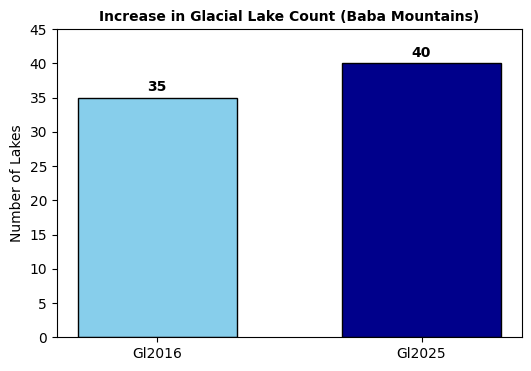

In [28]:
import matplotlib.pyplot as plt

# Data for plotting
years = ['Gl2016', 'Gl2025']
counts = [count_16, count_25]

plt.figure(figsize=(6, 4))
plt.bar(years, counts, color=['skyblue', 'darkblue'], edgecolor='black', width=0.6)

# Adding labels and title
plt.title('Increase in Glacial Lake Count (Baba Mountains)', fontsize=10, fontweight='bold')
plt.ylabel('Number of Lakes')
plt.ylim(0, 45) 

# Adding the count labels on top of bars
for i, v in enumerate(counts):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.show()

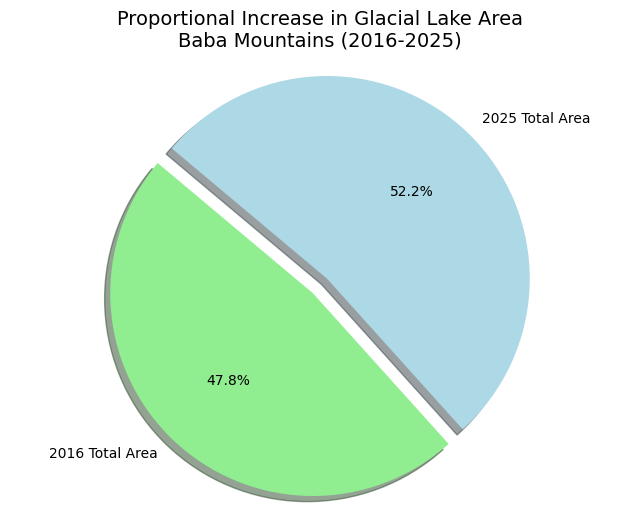

In [33]:
import matplotlib.pyplot as plt

# Data calculations
labels = ['2016 Total Area', '2025 Total Area']
areas = [0.570, 0.623]
colors = ['lightgreen', 'lightblue']  
explode = (0, 0.1)  

# Creating the Pie Chart
plt.figure(figsize=(8, 6))
plt.pie(areas, explode=explode, labels=labels, colors=colors, 
        autopct='%0.1f%%', shadow=True, startangle=140) 

plt.title('Proportional Increase in Glacial Lake Area\nBaba Mountains (2016-2025)', fontsize=14)
plt.axis('equal') 
plt.show()

## Observations:
The number of glacial lake increased from 35 to 40 between 2016 and 2025 as well as the area shows a total increase of 9.3%

2016 Elevation Class Distribution:
Elev_Class
High (Above 4000m)    34
Low (Below 4000m)      1
Name: count, dtype: int64

2025 Elevation Class Distribution:
Elev_Class
High (Above 4000m)    39
Low (Below 4000m)      1
Name: count, dtype: int64


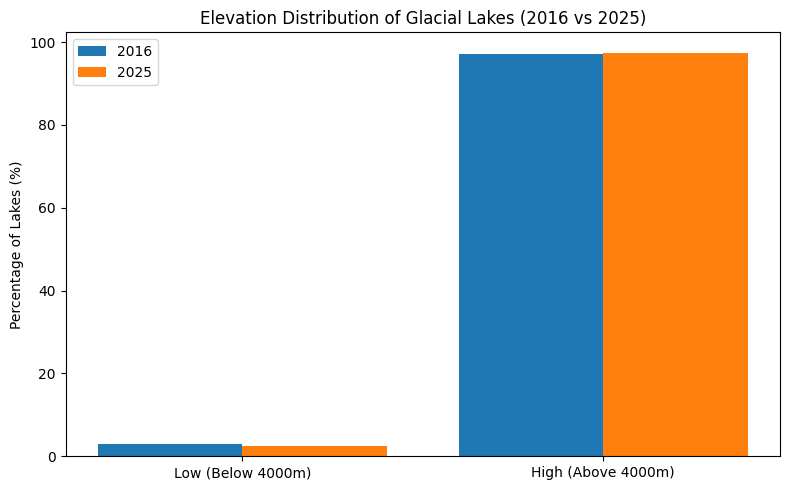

In [37]:
import pandas as pd

# Defining elevation bins and labels
# in Hindu Kush Himalaya region, the elevation of glacial lakes typically ranges from around 2200 meters to over 6200 meters.
# in Baba Mountains, the elevation of glacial lakes typically ranges from around 3000 meters to over 5000 meters.
# 3000-4000m (Low), 4000-5000m (High)
bins = [0, 4000, 5000]
labels = ['Low (Below 4000m)', 'High (Above 4000m)']

# Apply bins to both datasets
Lakes_16['Elev_Class'] = pd.cut(Lakes_16['Altitude'], bins=bins, labels=labels)
lakes_25['Elev_Class'] = pd.cut(lakes_25['Altitude'], bins=bins, labels=labels)


print('2016 Elevation Class Distribution:')
print(Lakes_16['Elev_Class'].value_counts())
print('\n2025 Elevation Class Distribution:')
print(lakes_25['Elev_Class'].value_counts())

import matplotlib.pyplot as plt

# Count values
counts_16 = Lakes_16['Elev_Class'].value_counts().sort_index()
counts_25 = lakes_25['Elev_Class'].value_counts().sort_index()

# Convert to percentage
perc_16 = counts_16 / counts_16.sum() * 100
perc_25 = counts_25 / counts_25.sum() * 100

# Create grouped bar chart
x = range(len(perc_16))

plt.figure(figsize=(8,5))
plt.bar([i - 0.2 for i in x], perc_16, width=0.4, label='2016')
plt.bar([i + 0.2 for i in x], perc_25, width=0.4, label='2025')

plt.xticks(x, perc_16.index)
plt.ylabel('Percentage of Lakes (%)')
plt.title('Elevation Distribution of Glacial Lakes (2016 vs 2025)')
plt.legend()
plt.tight_layout()
plt.show()


### Observation:
Between 2016 and 2025, a significant spatial shift in glacial lake distribution was observed. While the total number of lakes increased from 35 to 40, this growth was exclusively concentrated above 4000m. This upward migration of lake formation indicates that the melting threshold in the Baba Mountains is ascending, consistent with regional warming trends that displace the snowline to higher elevations.

### Spatial Join
To identify the number of new lakes created in between 2016 - 2025, I want to do spatial join between two layers. 

In [10]:
import geopandas as gpd

lake_16 = gpd.read_file('../Data/gl2016.geojson')
lake_25 = gpd.read_file('../Data/gl2025.geojson')

# Reproject to UTM Zone 42N (EPSG:32642)
lakes_16_proj = lake_16.to_crs(epsg=32642)
lakes_25_proj = lake_25.to_crs(epsg=32642)

# Spatial Join
joined = gpd.sjoin(
    lakes_25_proj,
    lakes_16_proj,
    how='left',
    predicate='intersects'
)

# Identify new vs existing lakes
new_lakes = joined[joined['index_right'].isna()]
existing_lakes = joined[joined['index_right'].notna()]

print(f"Number of NEW lakes formed since 2016: {len(new_lakes)}")
print(f"Number of existing (intersecting) lakes: {len(existing_lakes)}")


Number of NEW lakes formed since 2016: 6
Number of existing (intersecting) lakes: 34


### Observation
The spatial join results show that six new glacial lakes formed between 2016 and 2025. Given that the total number of lakes increased from 35 to 40, this indicates active glacial lake development during this period. At the same time, one previously mapped lake dried out.
These changes reflect the dynamic nature of glacier retreat and meltwater processes in the Baba Mountain region.

### Visualization
To visually compare lake boundaries across time and assess spatial changes in lake extent I want to add both layers (2016 & 2025) on sentinel 2 imageries that I have used for 2025 glaciel lakes extractions. 
For the initial image classification I have used these imageries: 
S2A_MSIL2A_20250919T061301_N0511_R134_T42SVD      
S2A_MSIL2A_20250919T061301_N0511_R134_T42SUD     
To load the imageries, the Google Earth Engine (GEE) Python API was imported into VS Code, and the Earth Engine project was initialized using authorized credentials. The filtered Sentinel-2 collection was then mosaicked and displayed as a base layer, with the 2016 and 2025 glacial lake polygons overlaid for comparison.

In [12]:
import ee
import geemap
import geopandas as gpd

# Initializing Earth Engine
ee.Initialize(project='geo5830')

# Point to Baba mountains.
poi = ee.Geometry.Point([67.100, 34.690])  

# Filter Sentinel-2 for BOTH tiles (42SUD + 42SVD)
s2_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2025-09-18', '2025-09-20')
    .filter(ee.Filter.inList('MGRS_TILE', ['42SUD', '42SVD']))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
)

# Checking how many images were found
n = s2_collection.size().getInfo()
print('Images found:', n)

# Create ONE map
m = geemap.Map()

# Visualization (False color composite for better lake visibility)
vis_params = {
    'bands': ['B11', 'B8', 'B4'],  # SWIR, NIR, Red for better water contrast
    'min': 0,
    'max': 4000,
    'gamma': 1.2
}

# Add Sentinel-2 mosaic
if n > 0:
    s2_image = s2_collection.mosaic()
    #m.centerObject(poi, 12)
    m.addLayer(s2_image, vis_params, 'Sentinel-2 Sept 19 2025 (2 tiles)')
else:
    print('No image found for these filters!')
    m.centerObject(poi, 12)

# Loading lake polygons (WGS84 for web mapping)
lake_25 = gpd.read_file('../Data/gl2025.geojson').to_crs(epsg=4326)
lake_16 = gpd.read_file('../Data/gl2016.geojson').to_crs(epsg=4326)

# Do spatial join in a projected CRS for accurate spatial operations
lake_25_proj = lake_25.to_crs(epsg=32642)
lake_16_proj = lake_16.to_crs(epsg=32642)

joined = gpd.sjoin(lake_25_proj, lake_16_proj, how='left', predicate='intersects')

new_lakes_proj = joined[joined['index_right'].isna()].copy()
# Back to EPSG:4326 for mapping
new_lakes = new_lakes_proj.to_crs(epsg=4326)

print("New lakes in 2025:", len(new_lakes))


# Center map on the 2025 lakes
xmin, ymin, xmax, ymax = lake_25.total_bounds
aoi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])
m.centerObject(aoi, 12)

# Add lake layers
m.add_gdf(
    lake_25,
    layer_name='Glacial Lakes 2025',
    style={'color': 'red', 'weight': 2}
)

m.add_gdf(
    lake_16,
    layer_name='Glacial Lakes 2016',
    style={'color': 'blue', 'weight': 2}
)

# Add NEW lakes layer on top (highlight)
m.add_gdf(
    new_lakes,
    layer_name='New Lakes in 2025',
    style={
        'color': None,          # remove outline
        'fillColor': 'yellow',    # yellow fill
        'fillOpacity': 0.6      # 60% transparency
    }
)
# Add legend
legend_dict = {
    'Glacial Lakes 2016': 'blue',
    'Glacial Lakes 2025': 'red',
    'New Glacial Lakes': 'yellow'
}
m.add_legend(title='Legend', legend_dict=legend_dict)

# Layer control toggle
m.addLayerControl()

m

Images found: 2
New lakes in 2025: 6


Map(center=[34.619523736300586, 67.84696045519588], controls=(WidgetControl(options=['position', 'transparent_…

For better understanding of the changes, I would like to load the same layers on to 2016 sentinel imageries that were used for 2016 glacial lakes data extractions. 
Images used :                                              
S2A_MSIL2A_20160924T060632_N0500_R134_T42SUD_20231028T071634   
S2A_MSIL2A_20160924T060632_N0500_R134_T42SVD_20231028T071634

In [13]:
import ee
import geemap
import geopandas as gpd

# Initialize Earth Engine
ee.Initialize(project='geo5830')

# Study area point
poi = ee.Geometry.Point([67.900, 34.690])


# Load 2016 Sentinel-2 imagery

s2_2016_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2016-09-24', '2016-09-25')
    .filter(ee.Filter.inList('MGRS_TILE', ['42SUD', '42SVD']))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
)

n2016 = s2_2016_collection.size().getInfo()
print("2016 Images found:", n2016)

m2016 = geemap.Map()

vis_params = {
    'bands': ['B11', 'B8', 'B4'],   # False color (good for water detection)
    'min': 0,
    'max': 4000,
    'gamma': 1.1
}

if n2016 > 0:
    s2_2016 = s2_2016_collection.mosaic()
    m2016.centerObject(poi, 12)
    m2016.addLayer(s2_2016, vis_params, 'Sentinel-2 Sept 24 2016 (2 tiles)')
else:
    print("No 2016 imagery found")
    m2016.centerObject(poi, 12)


# Load lake layers

lake_25 = gpd.read_file('../Data/gl2025.geojson').to_crs(epsg=4326)
lake_16 = gpd.read_file('../Data/gl2016.geojson').to_crs(epsg=4326)


# Add lakes on 2016 imagery

m2016.add_gdf(
    lake_16,
    layer_name='Glacial Lakes 2016',
    style={'color': 'blue', 'weight': 2}
)

m2016.add_gdf(
    lake_25,
    layer_name='Glacial Lakes 2025',
    style={'color': 'red', 'weight': 2}
)


# Add legend

legend_dict = {
    'Glacial Lakes 2016': 'blue',
    'Glacial Lakes 2025': 'red'
}

m2016.add_legend(title='Legend', legend_dict=legend_dict)
m2016.addLayerControl()

m2016

2016 Images found: 2


Map(center=[34.690000000000005, 67.90000000000002], controls=(WidgetControl(options=['position', 'transparent_…

In [25]:
import ee
import geemap
import geopandas as gpd


#Initialize Earth Engine
ee.Initialize(project='geo5830')


# Load Sentinel-2 Imagery
#2025 imageries 
s2_2025_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2025-09-18', '2025-09-20')
    .filter(ee.Filter.inList('MGRS_TILE', ['42SUD', '42SVD']))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
)

n2025 = s2_2025_collection.size().getInfo()
print('2025 images found:', n2025)

s2_2025 = s2_2025_collection.mosaic() if n2025 > 0 else None

#2016 imageries
s2_2016_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2016-09-24', '2016-09-25')
    .filter(ee.Filter.inList('MGRS_TILE', ['42SUD', '42SVD']))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
)

n2016 = s2_2016_collection.size().getInfo()
print('2016 images found:', n2016)

s2_2016 = s2_2016_collection.mosaic() if n2016 > 0 else None


#Load Glacial lake layers

lake_25 = gpd.read_file('../Data/gl2025.geojson').to_crs(epsg=4326)
lake_16 = gpd.read_file('../Data/gl2016.geojson').to_crs(epsg=4326)

# Identify NEW Glacial lakes

lake_25_proj = lake_25.to_crs(epsg=32642)
lake_16_proj = lake_16.to_crs(epsg=32642)

joined = gpd.sjoin(lake_25_proj, lake_16_proj, how='left', predicate='intersects')

new_lakes = (
    joined[joined['index_right'].isna()]
    .copy()
    .to_crs(epsg=4326)
)

print('New lakes in 2025:', len(new_lakes))


# Creating Interactive Map
m = geemap.Map()

# Safe centering using lakes extent
xmin, ymin, xmax, ymax = lake_25.total_bounds
center_lon = (xmin + xmax) / 2
center_lat = (ymin + ymax) / 2
m.set_center(center_lon, center_lat, 12)


#Visualization parameters
vis_params = {
    'bands': ['B11', 'B8', 'B4'],   # SWIR-NIR-Red (great for water)
    'min': 0,
    'max': 4000,
    'gamma': 1.1,
}


# Add imagery layers
# 2025 FIRST (bottom)
# 2016 SECOND (top)


if s2_2025 is not None:
    m.addLayer(s2_2025, vis_params, 'Sentinel-2 Sept 19 2025 (2 tiles)')
else:
    print(' 2025 imagery not found')

if s2_2016 is not None:
    m.addLayer(s2_2016, vis_params, 'Sentinel-2 Sept 24 2016 (2 tiles)')
else:
    print(' 2016 imagery not found')


# make 2016 semi-transparent for comparison
m.layers[-1].opacity = 0.7


# Adding lake layers


m.add_gdf(
    lake_16,
    layer_name='Glacial Lakes 2016',
    style={'color': 'blue', 'weight': 2}
)

m.add_gdf(
    lake_25,
    layer_name='Glacial Lakes 2025',
    style={'color': 'red', 'weight': 2}
)

# New lakes — fill only
m.add_gdf(
    new_lakes,
    layer_name='New Lakes in 2025',
    style={
        'weight': 0,
        'fillColor': 'yellow',
        'fillOpacity': 0.6,
    }
)


#Legend + Layer control

legend_dict = {
    'Glacial Lakes 2016': 'blue',
    'Glacial Lakes 2025': 'red',
    'New Lakes in 2025': 'yellow',
}

m.add_legend(title='Legend', legend_dict=legend_dict)
m.addLayerControl()

m

2025 images found: 2
2016 images found: 2
New lakes in 2025: 6


Map(center=[np.float64(34.619319605184515), np.float64(67.84696045519584)], controls=(WidgetControl(options=['…